In [78]:
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import textwrap

# Функция для извлечения координат из файла
def coordinates_extraction(file_path, is_clinics=True):
    # Регулярное выражение для поиска координат и названий
    if is_clinics:
        pattern = r"([^(]+)\s*\(([-\d.]+),\s*([-\d.]+)\)\s*([^\n]*)"
    else:
        pattern = r"([^\(]+)\s*\(([-\d.]+),\s*([-\d.]+)\)"
    
    # Список для хранения координат и названий
    coordinates = []
    
    # Чтение файла
    with open(file_path, 'r', encoding='utf-8') as file:
        # Обрабатываем строки из файла
        for line in file:
            matches = re.findall(pattern, line)
            for match in matches:
                name = match[0].strip()
                x, y = round(float(match[1]), 6), round(float(match[2]), 6)
                if is_clinics:
                    actual_district = match[3].strip()
                    coordinates.append([name, x, y, actual_district])
                else:
                    coordinates.append([name, x, y])
    
    return coordinates


# Функция нормализации координат в диапазон [0,1]
def normalize_coordinates(data):
    coords = np.array([[c[1], c[2]] for c in data])
    min_vals = coords.min(axis=0)
    max_vals = coords.max(axis=0)
    normalized = (coords - min_vals) / (max_vals - min_vals)
    return [[data[i][0], *normalized[i]] for i in range(len(data))]


# Функция для вычисления Евклидова расстояния
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((np.array(p1) - np.array(p2))**2))

# Функция для обучения нейронной сети Кохонена
def kohonen_network(clinics, weights, learning_rate=0.3, num_epochs=10, cluster_names=None):

    weights = np.array([[c[1], c[2]] for c in weights])

    # Визуализация начальных весов (до обучения)    
    plot_clustering(clinics, weights, epoch=0, cluster_names=cluster_names)
    
    # Обучение сети
    for epoch in range(num_epochs):
        learning_rate_epoch = learning_rate * (1 - epoch / num_epochs)  # Уменьшение скорости обучения
    
        for clinic in clinics:
            
            input_vector = np.array([float(c) for c in clinic[1:3]])  # Преобразуем в числовой вектор
            # Вычисляем расстояние от поликлиники до каждого округа
            distances = np.array([euclidean_distance(input_vector, w) for w in weights])
            
            # Нейрон (округ) с минимальным расстоянием побеждает
            winning_neuron = np.argmin(distances)
            # Обновление весов победившего нейрона (округа)
            weights[winning_neuron] += learning_rate_epoch * (input_vector - weights[winning_neuron])
        
        # Визуализация после каждой эпохи
        plot_clustering(clinics, weights, epoch + 1, cluster_names=cluster_names)
    
    return weights


def plot_clustering(clinics, weights, epoch, cluster_names):
    clinics_coords = np.array([[c[1], c[2]] for c in clinics])
    cluster_coords = np.array(weights)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(clinics_coords[:, 0], clinics_coords[:, 1], c='blue', label='Поликлиники', marker='o')
    plt.scatter(cluster_coords[:, 0], cluster_coords[:, 1], c='red', label='Кластеры (центры)', marker='x')

    # Подписываем кластеры
    for i, (x, y) in enumerate(cluster_coords):
        plt.text(x, y, cluster_names[i], fontsize=9, ha='right', va='bottom', color='red', fontweight='bold')

    for i, clinic in enumerate(clinics):
        winner = np.argmin([euclidean_distance([clinic[1], clinic[2]], w) for w in weights])  # Исправлено
        plt.plot([clinic[1], weights[winner, 0]], [clinic[2], weights[winner, 1]], 'gray', linestyle='--')
    
    if epoch == 0:
        plt.title(f"Распределение поликлиник по кластерам (до обучения)")  
    else:
        plt.title(f"Распределение поликлиник по кластерам (Эпоха {epoch})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Функция для кластеризации (определяем победивший нейрон для каждой клиники)
def kohonen_clustering(clinics, weights, cluster_names):
    assignments = []
    for clinic in clinics:
        # Вычисление расстояний между входным вектором и весами нейронов
        distances = np.array([euclidean_distance([clinic[1], clinic[2]], w) for w in weights])  # Исправлено
        
        # Нейрон с минимальным расстоянием побеждает
        winning_neuron = np.argmin(distances)
        predicted_district = cluster_names[winning_neuron]
        assignments.append((winning_neuron, predicted_district))
    
    return assignments

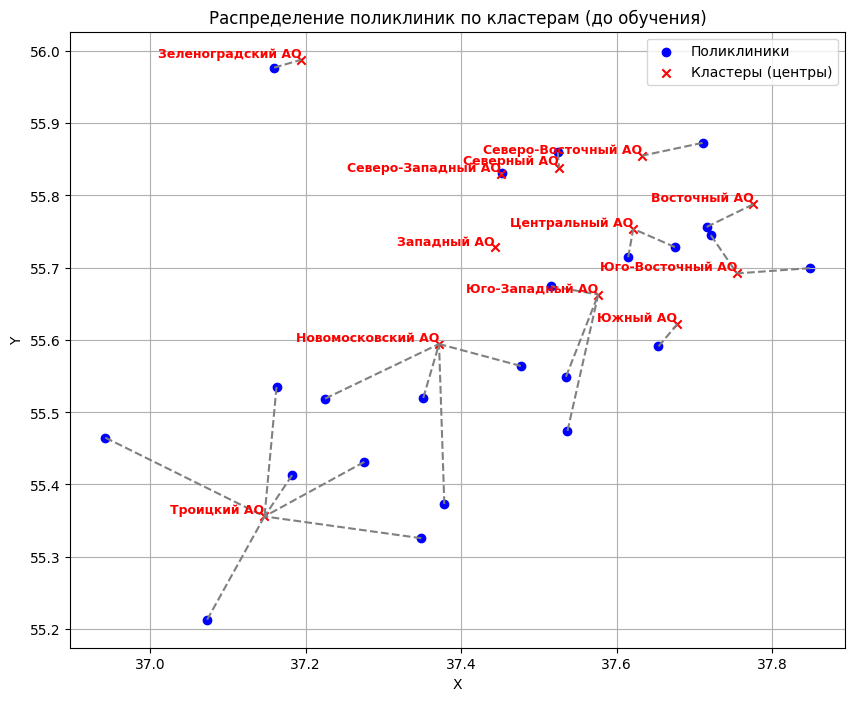

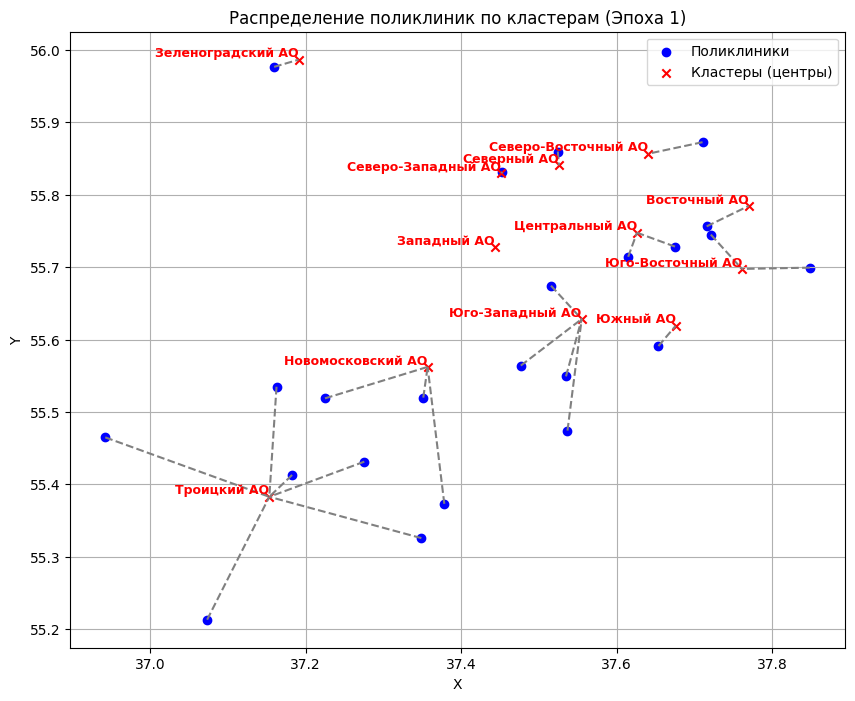

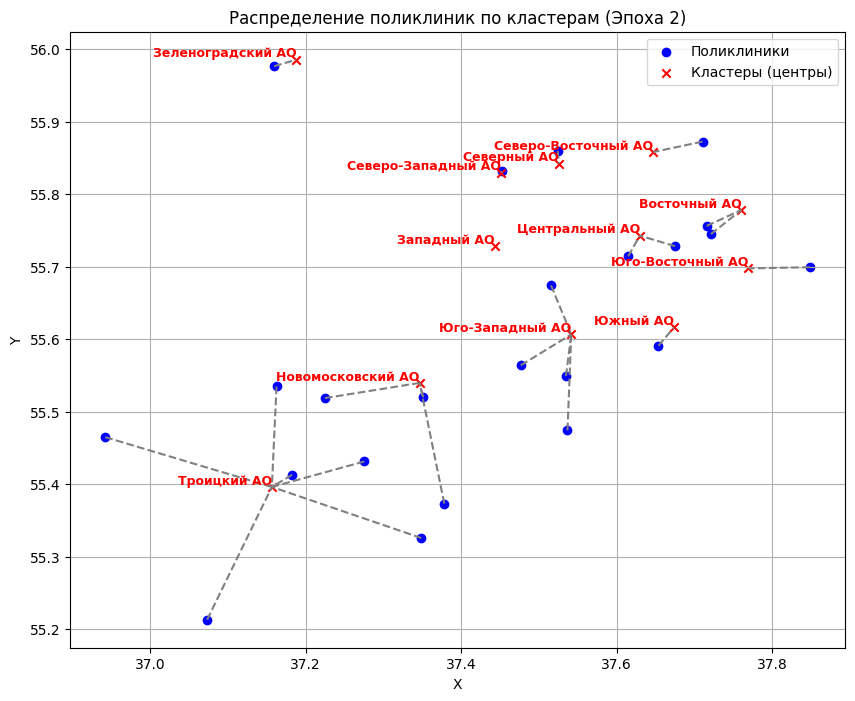

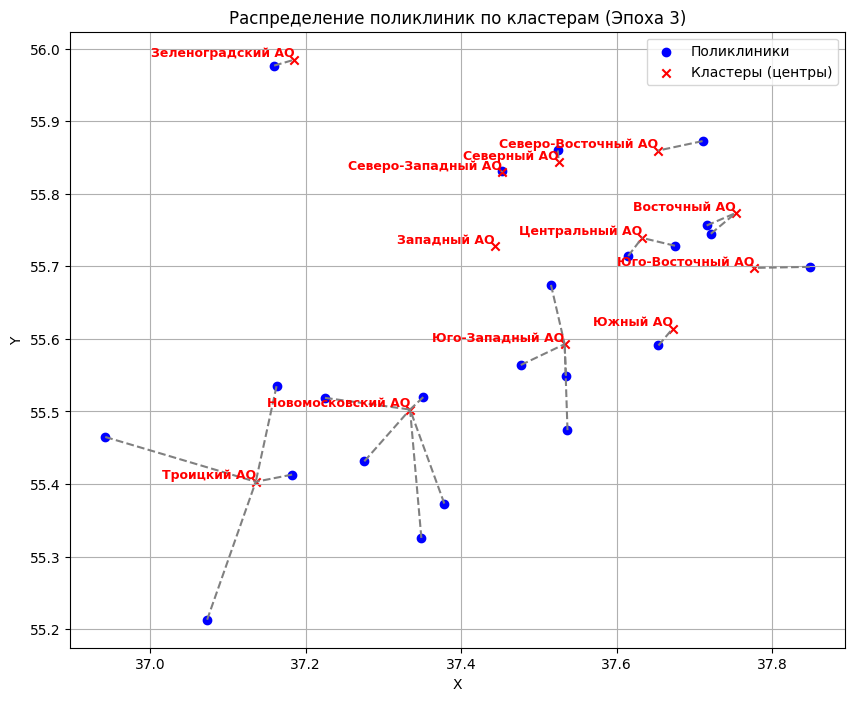

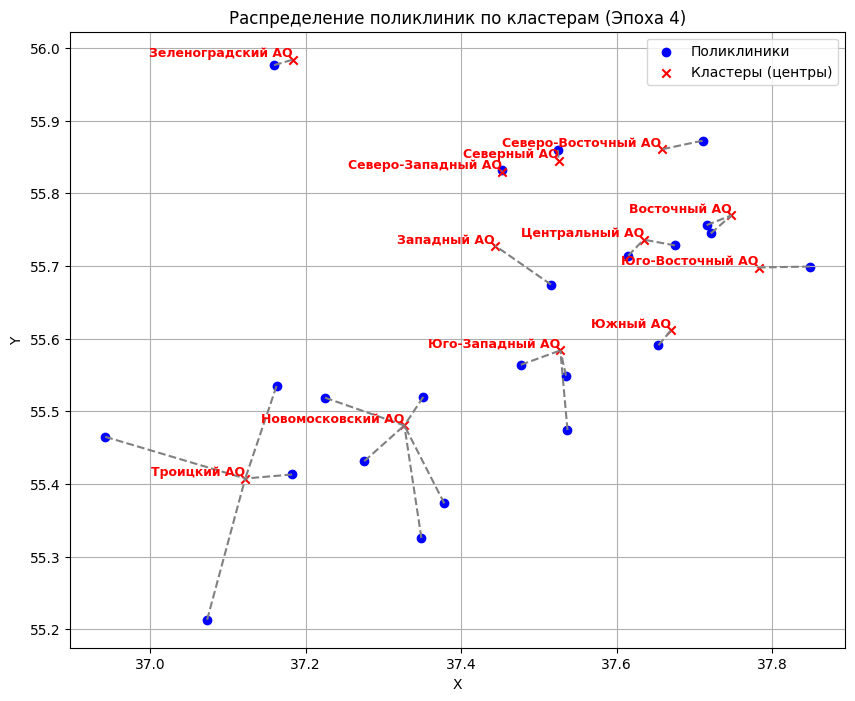

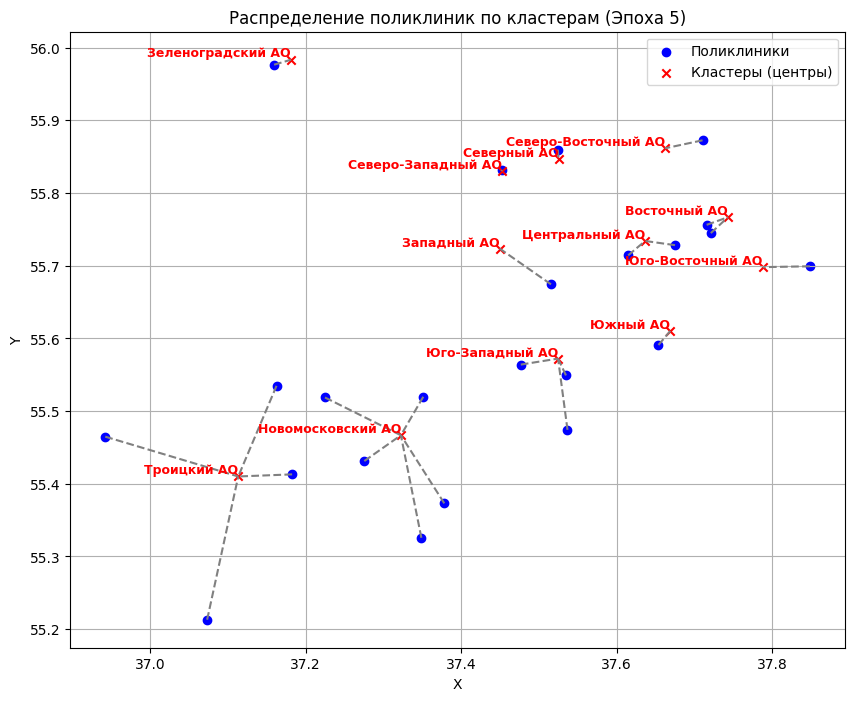

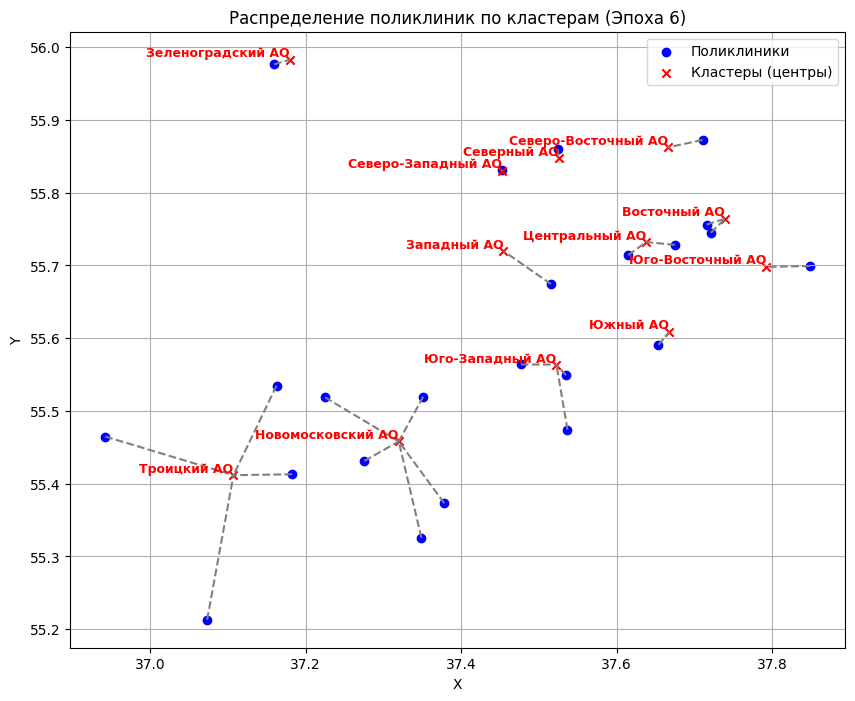

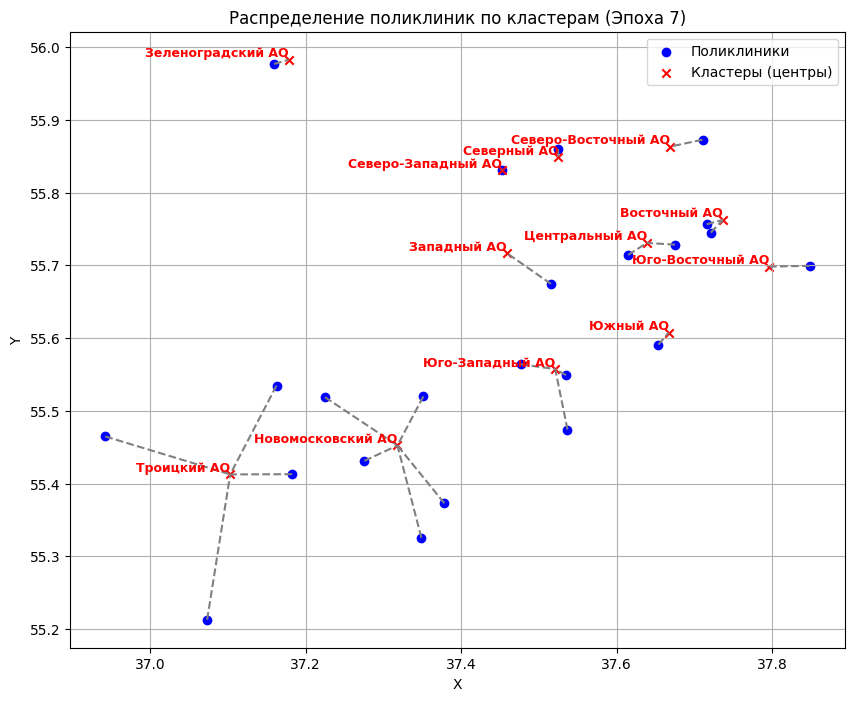

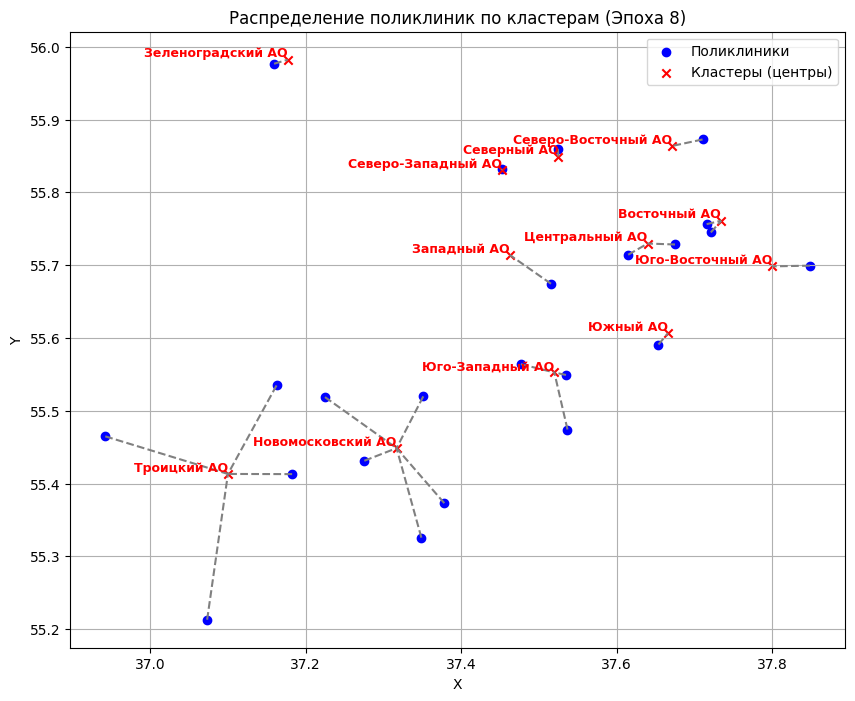

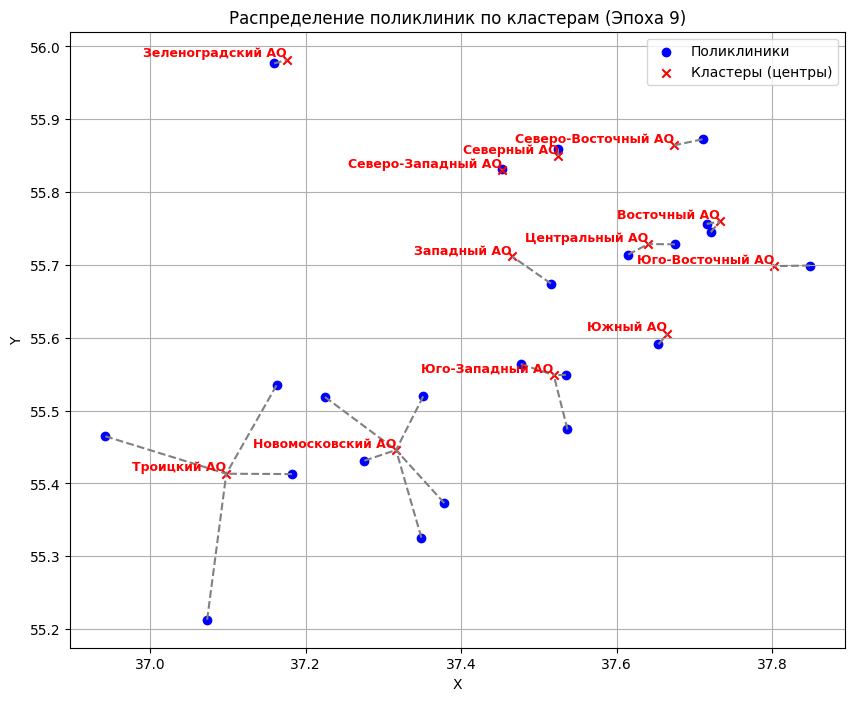

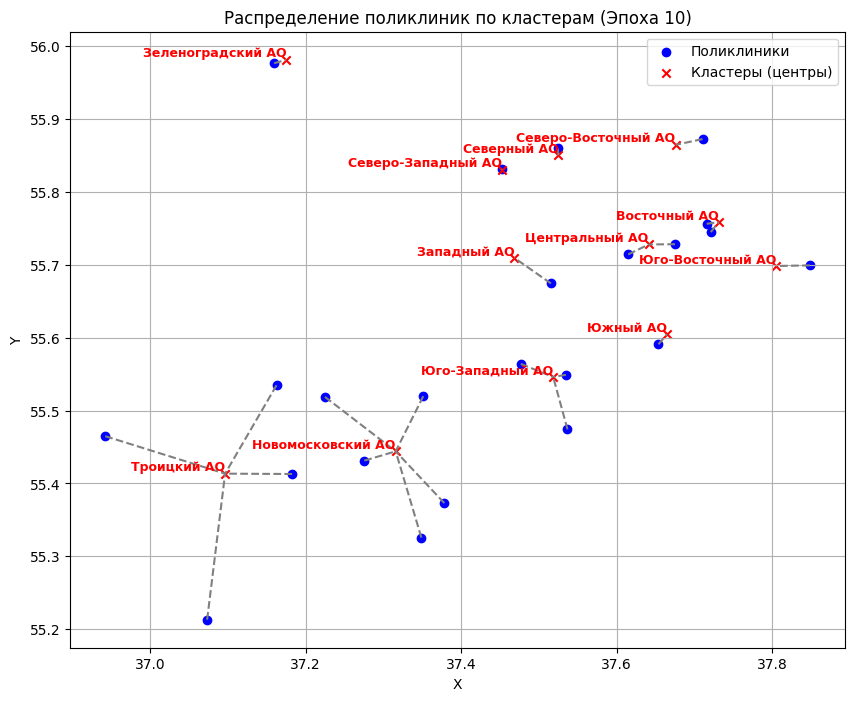

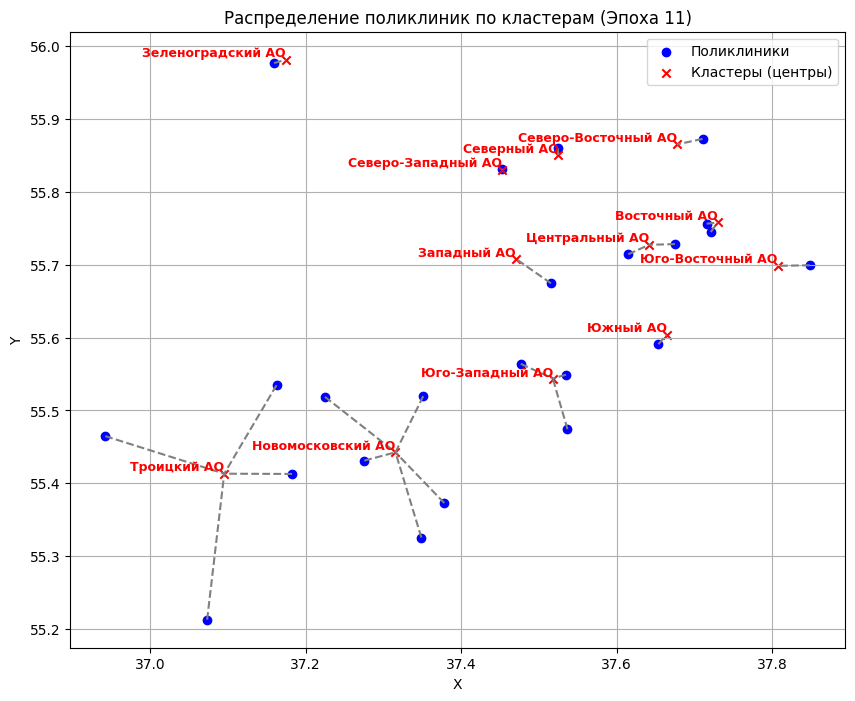

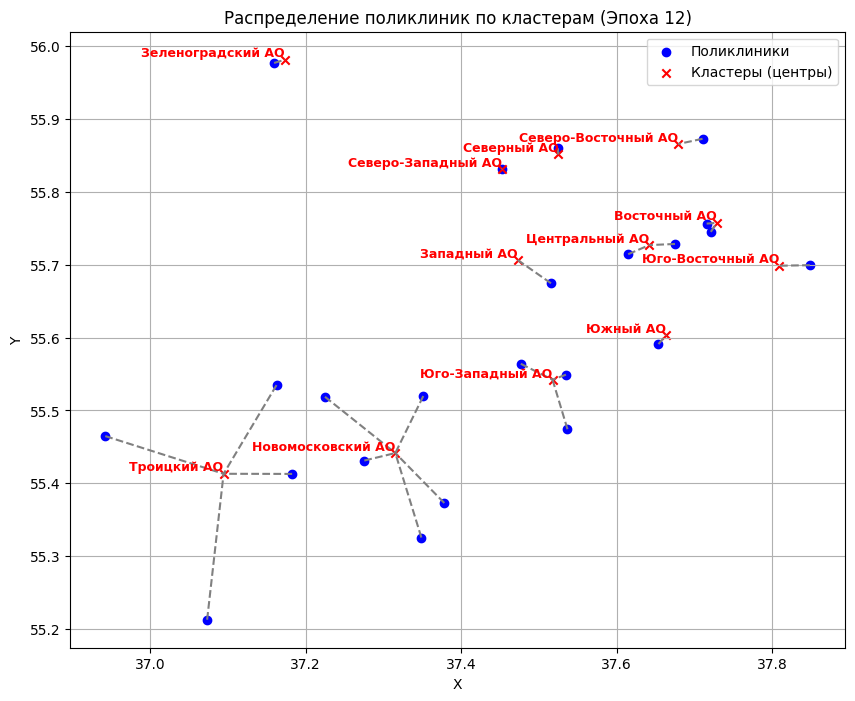

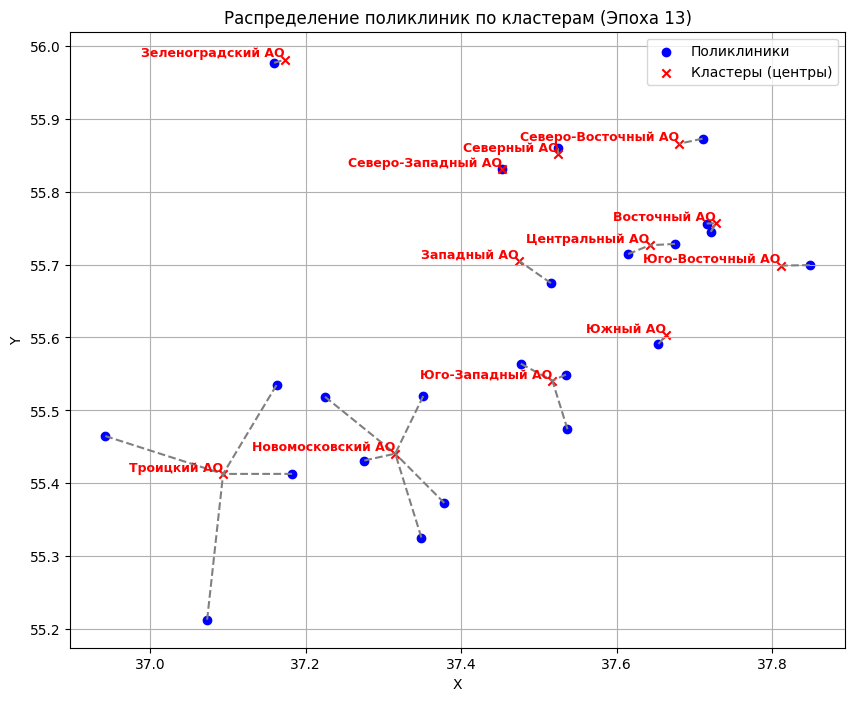

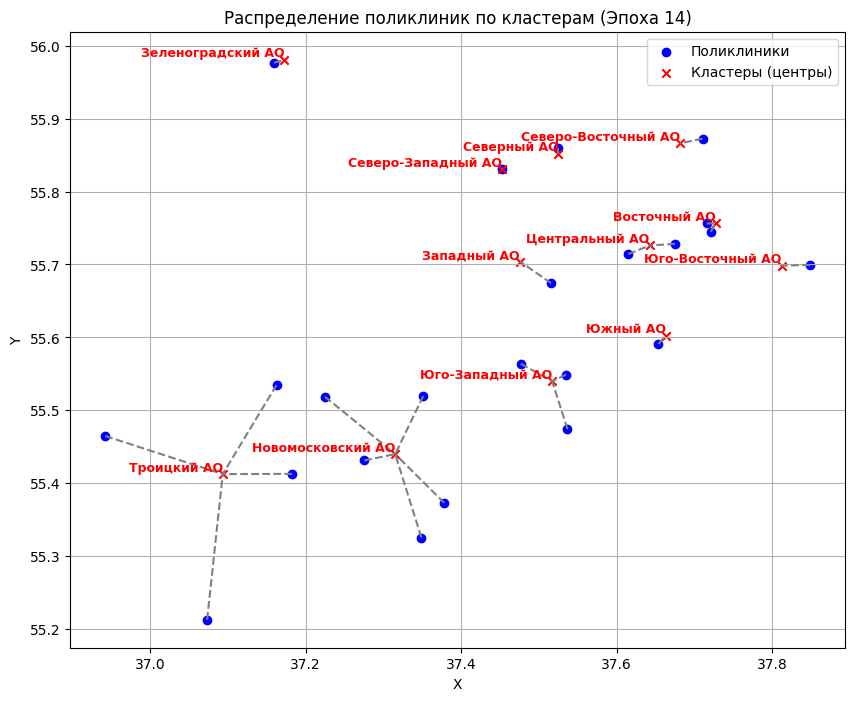

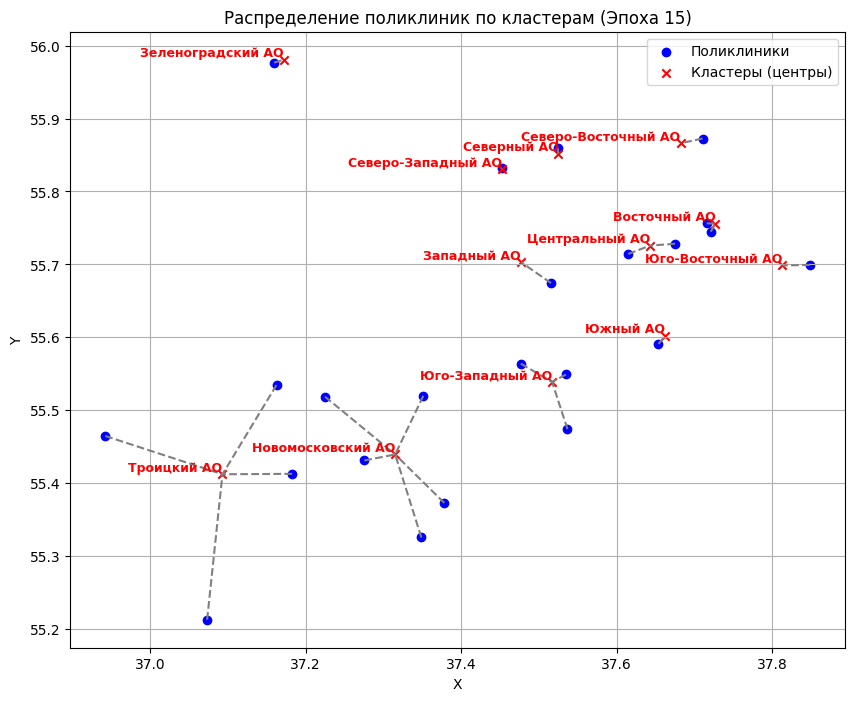

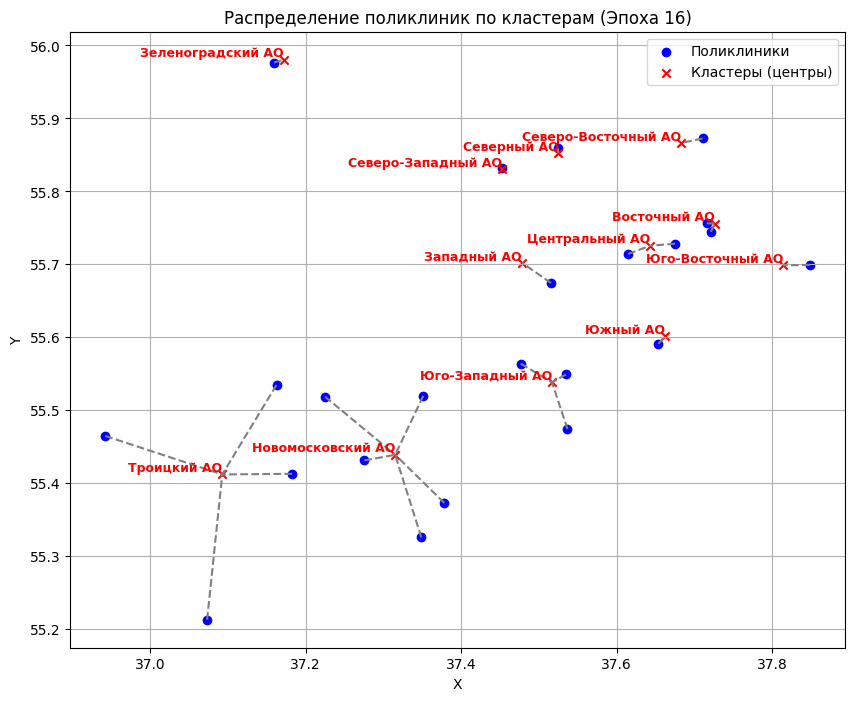

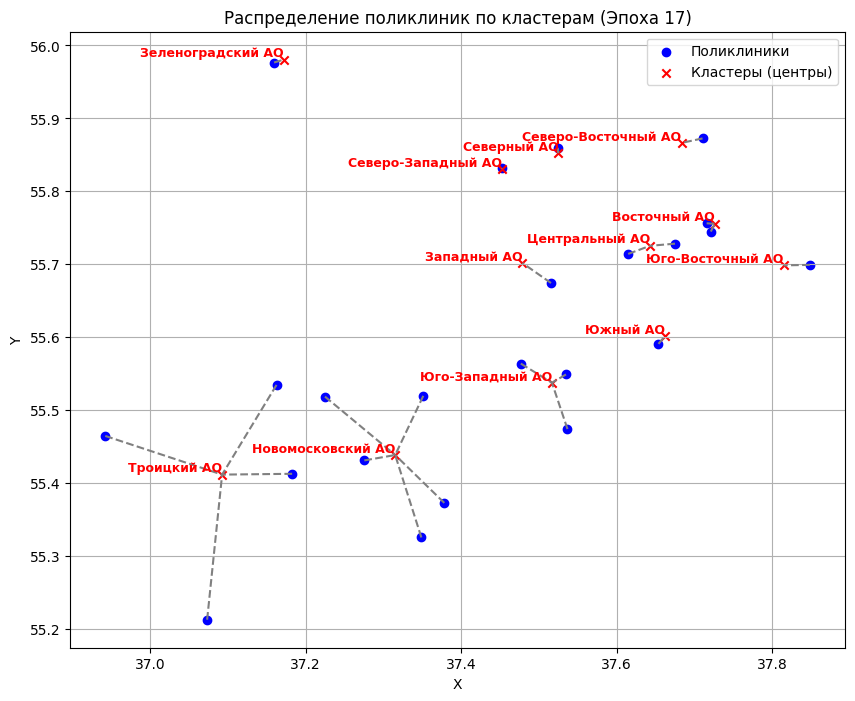

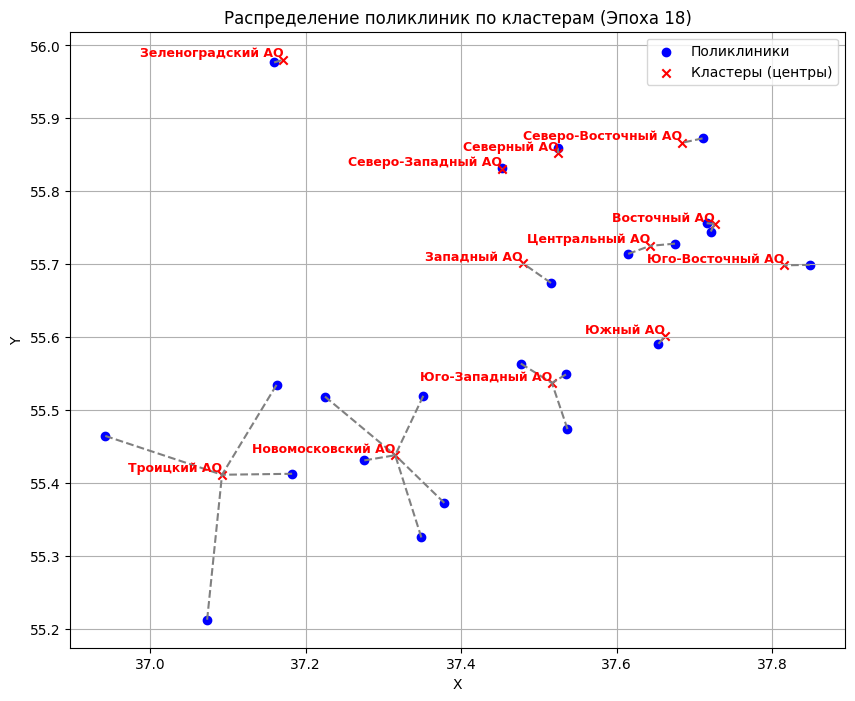

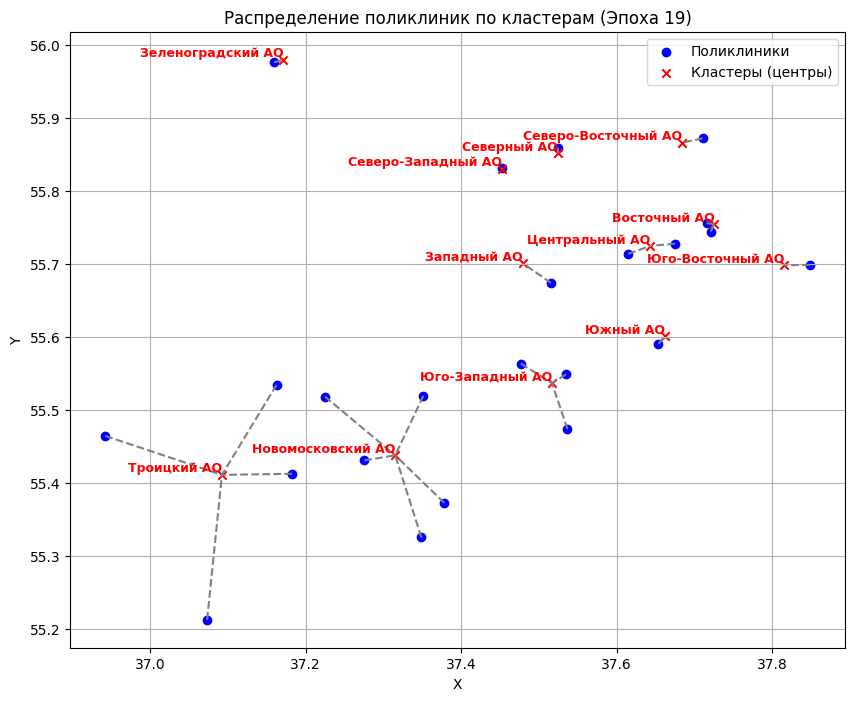

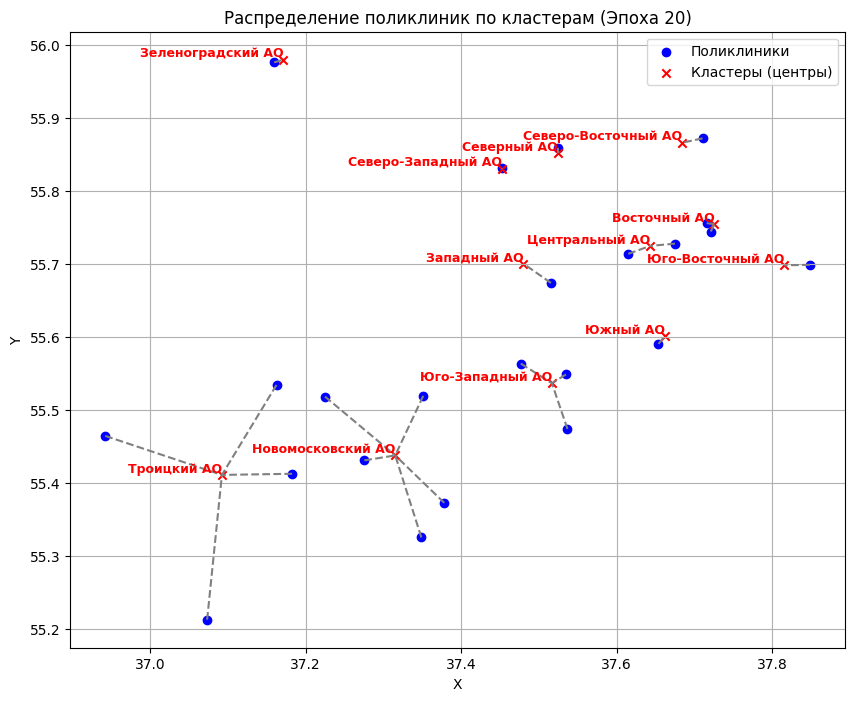


Итоговые веса:
Центральный АО: [37.642845 55.725144]
Северный АО: [37.524732 55.852517]
Северо-Восточный АО: [37.684109 55.86661 ]
Восточный АО: [37.725511 55.755219]
Юго-Восточный АО: [37.815531 55.698603]
Южный АО: [37.661843 55.601427]
Юго-Западный АО: [37.516568 55.536985]
Западный АО: [37.479705 55.701025]
Северо-Западный АО: [37.452197 55.830806]
Зеленоградский АО: [37.171088 55.980303]
Новомосковский АО: [37.315101 55.438093]
Троицкий АО: [37.092233 55.41137 ]

Название поликлиники                               Прогнозируемый округ           Действительный округ          
----------------------------------------------------------------------------------------------------------------------------------
ГАУЗ СП № 66 ДЗМ                                   Центральный АО                 Центральный АО                
ГБУЗ ГКБ № 1 им.Н.И. Пирогова ДЗМ филиал ЧЛГ...    Центральный АО                 Южный АО                      
________________________________________________________

In [79]:
# Открываем файлы с данными
clinics_path = "clinics.txt"  # Путь к файлу с координатами поликлиник
clusters_path = "clusters.txt" # Путь к файлу с координатами кластеров
clinics = coordinates_extraction(clinics_path, is_clinics=True)  # Извлекаем данные для поликлиник
clusters = coordinates_extraction(clusters_path, is_clinics=False)  # Извлекаем данные для кластеров

# Преобразуем координаты в массивы numpy для дальнейшей обработки
clinics_coords = np.array([[float(c[1]), float(c[2])] for c in clinics])  # Координаты поликлиник
cluster_coords = np.array([[float(c[1]), float(c[2])] for c in clusters])  # Координаты кластеров
cluster_names = [c[0] for c in clusters]  # Названия кластеров

# Параметры обучения нейронной сети Кохонена
eta = 0.1   # Коэффициент обучения
epochs = 20   # Количество эпох

# Кластеризация с обучением нейронной сети Кохонена
weights = kohonen_network(clinics, clusters, eta, epochs, cluster_names)  # Обучение сети
# Получаем присвоенные кластеры для каждой клиники
assignments = kohonen_clustering(clinics, weights, cluster_names)

# Выводим итоговые веса
print("\nИтоговые веса:")
for i, weight in enumerate(weights):
    rounded_weight = np.round(weight, 6)  # Округляем каждый компонент веса
    print(f"{cluster_names[i]}: {rounded_weight}")  # Выводим веса для каждого кластера

# Группируем результаты кластеризации: ключ – название округа, значение – список (название поликлиники, действительный округ)
results = defaultdict(list)
mismatches = 0  # Счётчик ошибок
total = len(clinics)  # Общее количество поликлиник

# Сравниваем прогнозируемые и действительные округа для каждой клиники
for clinic, assignment in zip(clinics, assignments):
    predicted_district = cluster_names[assignment[0]]  # Прогнозируемый округ
    
    # Преобразуем название поликлиники в действительный округ
    actual_district = clinic[3]  # Используем действительный округ, который мы извлекли из данных поликлиники
    
    # Если прогнозируемый и действительный округ не совпадают, увеличиваем счётчик ошибок
    if predicted_district != actual_district:
        mismatches += 1
    
    # Добавляем клинику в результаты кластеризации по округу
    results[predicted_district].append((clinic[0], actual_district))

# Выводим таблицу с результатами кластеризации
print("\n{:<50} {:<30} {:<30}".format("Название поликлиники", "Прогнозируемый округ", "Действительный округ"))
print("-" * 130)

# Печатаем данные для каждого округа
for district in cluster_names:
    entries = sorted(results.get(district, []))  # Сортируем по названиям клиник
    if entries:
        for clinic_name, actual_district in entries:
            # Обрезаем название клиники до 50 символов и добавляем многоточие, если оно длиннее
            shortened_name = textwrap.shorten(clinic_name, width=50, placeholder="...")
            print("{:<50} {:<30} {:<30}".format(shortened_name, district, actual_district))  # Выводим строку для каждой клиники
    else:
        print("{:<50} {:<30} {:<30}".format("Нет назначенных клиник", district, "-"))  # Если нет клиник для этого округа
    
    print("_" * 130)

# Подсчёт и вывод ошибки
error_percent = (mismatches / total) * 100  # Вычисляем процент ошибок
print(f"\nСуммарная ошибка кластеризации: {mismatches} из {total} ({error_percent:.2f}%)")